# JUMP adipocyte → AnnData

Adipocyte Cell Painting ([`cpg0014`](https://broadinstitute.github.io/cellpainting-gallery/)), a differentiated cell system rather than a cancer line.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0014-jump-adipocyte/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0014-jump-adipocyte/profiles").expanduser()

## Scoping to one batch

Feature selection ran per batch, so batches carry different feature sets and intersecting across them throws most features away.
This takes the batch with the most plates.

In [2]:
batches = sorted({p.parents[1].name for p in PROFILES.glob("*/*/*.csv.gz")})
BATCH = max(batches, key=lambda b: len(list((PROFILES / b).glob("*/*"))))
print(f"{len(batches)} batches, using {BATCH}")
files = sorted((PROFILES / BATCH).glob("*/*"))

5 batches, using 2022_11_28_Batch1


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 2}, on_column_mismatch="intersect"
)
adata

AnnData object with n_obs × n_vars = 9216 × 853
    obs: 'broad_sample', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_CellsIncludingEdges', 'Count_Cytoplasm', 'Count_Nuclei', 'Count_NucleiIncludingEdges', 'Object_Count', 'solvent', 'plate_map_name', 'mg_per_ml', 'mmoles_per_liter', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "plate_map_name", "pert_type", "control_type"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Image_Granularity_10_AGP,image,granularity,agp,NaN,1
Image_Granularity_10_BFHigh,image,granularity,brightfield_high,NaN,1
Image_Granularity_10_ER,image,granularity,er,NaN,1
Image_Granularity_10_Mito,image,granularity,mito,NaN,1
Image_Granularity_10_RNA,image,granularity,rna,NaN,1
...,...,...,...,...,...
Nuclei_Texture_InfoMeas2_DNA_3_02_256,nuclei,texture,dna,NaN,1
Nuclei_Texture_InfoMeas2_Mito_3_00_256,nuclei,texture,mito,NaN,1
Nuclei_Texture_SumEntropy_AGP_10_01_256,nuclei,texture,agp,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["Plate", "plate_map_name"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

9,216 wells x 848 features
non-finite: 0 | max|x|: 10571.0

Plate:
Plate
BR00135656    384
BR00135657    384
BR00135658    384
BR00135659    384
BR00135660    384
BR00135661    384

plate_map_name:
plate_map_name
S-B-REPO1_2020-004-1    1920
S-B-REPO1_2020-005-1    1920
S-B-REPO1_2020-006-1    1920
S-B-REPO1_2020-007-1    1920
<NA>                    1536


In [6]:
adata.write_h5ad(PROFILES.parent / "jump_adipocyte.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "plate_map_name", "pert_type"]))

,observed,baseline,ratio
covariate,,,
Plate,0.209,0.042,5.024
plate_map_name,0.380,0.250,1.520


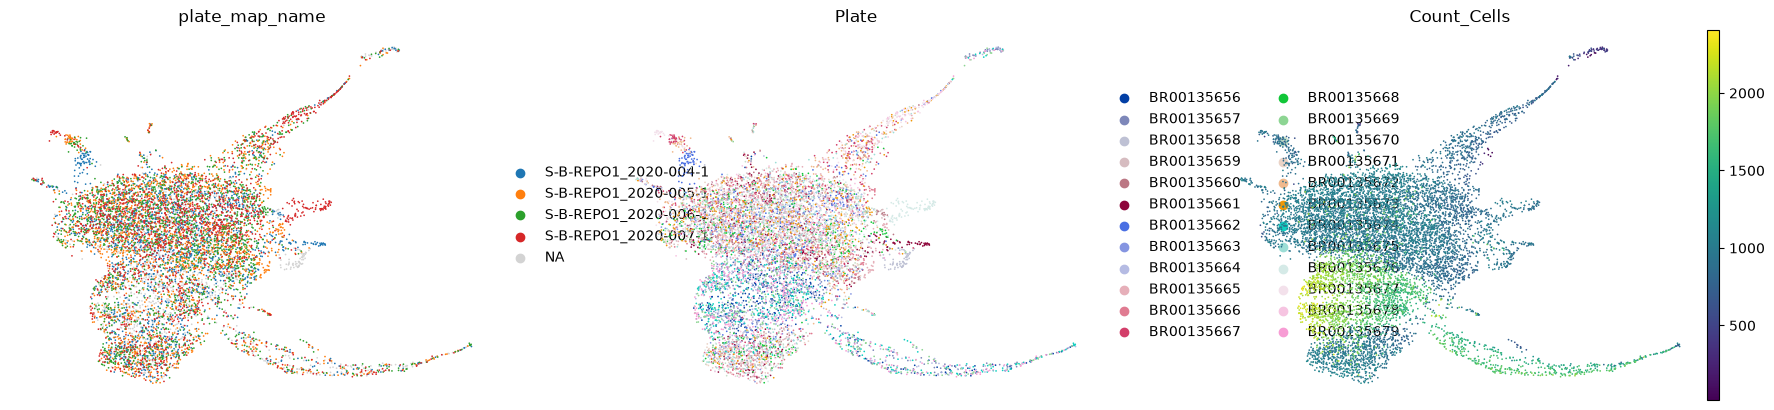

In [9]:
sc.pl.umap(adata, color=present(["plate_map_name", "Plate", "Count_Cells"])[:3], ncols=3, frameon=False, size=6)